## Определение возраста покупателей для сетевого супермаркета «Хлеб-Соль»

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

    Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
    Контролировать добросовестность кассиров при продаже алкоголя.

Нужно построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

Нашей метрикой качества будет MAE — если мы получим MAE меньше 7, это будет хороший результат.

# Определение возраста покупателей

## Исследовательский анализ данных

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
def decl_of_num(num: int, titles: tuple[str, str, str]) -> str:
    cases = (2, 0, 1, 1, 1, 2)
    title = titles[2 if (num % 100 > 4 and num % 100 < 20) else cases[min(num % 10, 5)]]
    return f'{num} {title}'

In [3]:
DATA_PATH = '/datasets/faces/'
RANDOM_STATE = 42

In [4]:
df = pd.read_csv(DATA_PATH + 'labels.csv')

In [5]:
df.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


Датасет содержит имя файла с фотографией и возраст(целевой признак)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


Пропусков нет


In [7]:
df.duplicated(subset='file_name').sum()

0

Дубликатов нет

In [8]:
df['real_age'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
real_age,7591.0,31.201159,17.14506,1.0,20.0,29.0,41.0,100.0


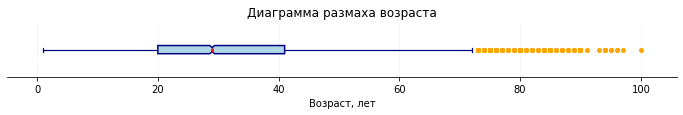

In [9]:
fig, ax = plt.subplots(figsize=(12, 1))

boxprops = dict(facecolor='lightblue', color='navy', linewidth=1.5)
medianprops = dict(color='red', linewidth=2.5, linestyle='--')
whiskerprops = dict(color='navy', linewidth=1.2)
capprops = dict(color='navy', linewidth=1.2)
flierprops = dict(marker='o', markerfacecolor='orange', markersize=5, markeredgecolor='none')

df['real_age'].plot(kind='box', vert=False, ax=ax, notch=True, patch_artist=True,
                   boxprops=boxprops, medianprops=medianprops,
                   whiskerprops=whiskerprops, capprops=capprops,
                   flierprops=flierprops)

ax.set_title('Диаграмма размаха возраста')
ax.set_xlabel('Возраст, лет')
ax.set_yticklabels([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.4, linestyle=':')

xlim = ax.get_xlim()
ax.set_xlim(xlim[0] - 1, xlim[1] + 1)

plt.show()

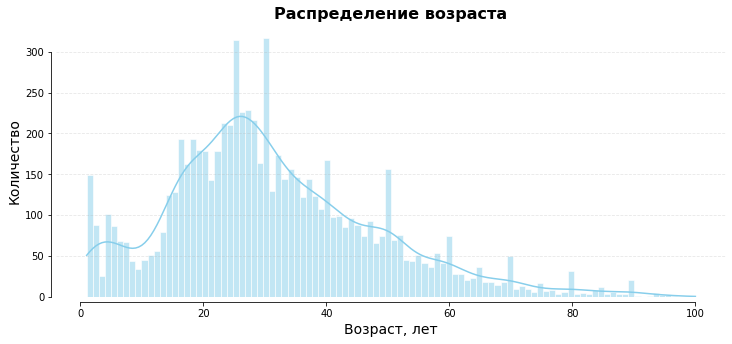

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    df['real_age'], bins=100, color='skyblue',
    kde=True,
    edgecolor='white', ax=ax)

ax.set_title('Распределение возраста', fontsize=16, fontweight='bold')
ax.set_xlabel('Возраст, лет', fontsize=14)
ax.set_ylabel('Количество', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

sns.despine(ax=ax, offset=5, trim=True)

plt.show()

Собраны люди в разных возрастах(от 1 года до 100 лет), большая часть на

In [11]:
datagen = ImageDataGenerator(rescale=1./255)

datagen_flow = datagen.flow_from_dataframe(
    dataframe=df,                       
    directory=DATA_PATH + 'final_files',     
    x_col='file_name',                       
    y_col='real_age',                       
    class_mode='raw',                          
    target_size=(224, 224),                   
    batch_size=32,                   
    shuffle=True,             
    seed=RANDOM_STATE
)

Found 7591 validated image filenames.


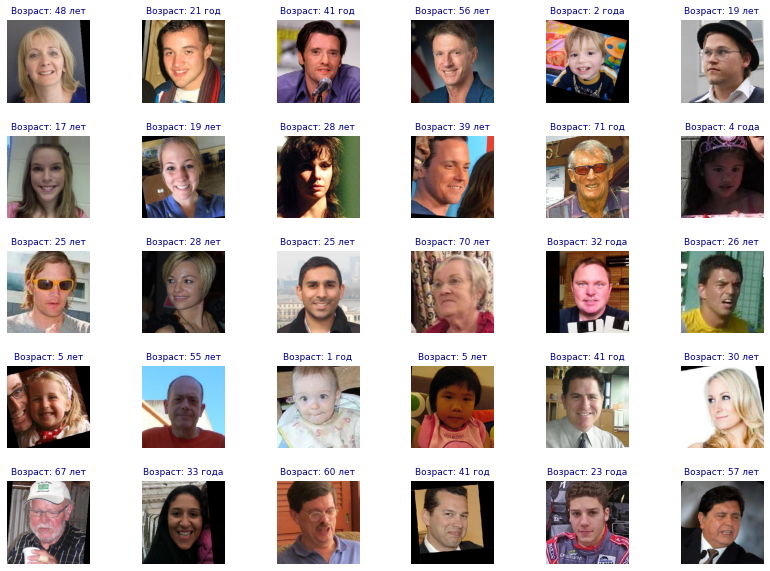

In [14]:
features_batch, target_batch = next(datagen_flow)

fig = plt.figure(figsize=(14, 10))
fig.subplots_adjust(wspace=0.25, hspace=0.4)

for idx in range(30):
    ax = fig.add_subplot(5, 6, idx + 1)
    ax.imshow(features_batch[idx])
    age_text = decl_of_num(target_batch[idx], ('год', 'года', 'лет'))
    ax.set_title(f'Возраст: {age_text}', fontsize=9, color='darkblue')
    ax.axis('off')
    
plt.show()

Имеются фотографии с обрезанными или частично закрытыми лицами, лица расположены вертикально, носы находятся по центру.Некоторые фото слегка повернуты

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

Модель на основе ResNet50

```python

def load_data(path, subset):
    labels_df = pd.read_csv(path + '/labels.csv')

    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )
    
    data_flow = datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory=path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        class_mode='raw',
        target_size=(224, 224),
        batch_size=32,
        shuffle=True if subset == 'training' else False,
        subset=subset,
        seed=RANDOM_STATE
    )

    return data_flow

def load_train(path):
    return load_data(path, subset='training')

def load_test(path):
    return load_data(path, subset='validation')

def create_model(input_shape):
    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dropout(0.5, seed=RANDOM_STATE),
        Dense(1, activation='relu') 
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mean_absolute_error', 
        metrics=['mae']
    )
    return model

def train_model(model, train_data, test_data, epochs=30, steps_per_epoch=None, validation_steps=None):
    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    preds = model.predict(test_data)
    print('Пример предсказаний возрастов:', ', '.join(f'{p[0]:.2f}' for p in preds[:10]))

    return model

```

```

Train for 178 steps, validate for 60 steps

Epoch 1/30

178/178 - 63s - loss: 11.8497 - mae: 11.8505 - val_loss: 24.9906 - val_mae: 25.0687

Epoch 2/30

178/178 - 38s - loss: 6.9930 - mae: 6.9928 - val_loss: 18.8675 - val_mae: 18.9496

Epoch 3/30

178/178 - 38s - loss: 5.7639 - mae: 5.7640 - val_loss: 15.3688 - val_mae: 15.4395

Epoch 4/30

178/178 - 37s - loss: 5.0403 - mae: 5.0407 - val_loss: 8.8151 - val_mae: 8.8218

Epoch 5/30

178/178 - 37s - loss: 4.5232 - mae: 4.5237 - val_loss: 6.7475 - val_mae: 6.7407

Epoch 6/30

178/178 - 37s - loss: 4.1664 - mae: 4.1670 - val_loss: 6.4310 - val_mae: 6.4245

Epoch 7/30

178/178 - 37s - loss: 3.9636 - mae: 3.9637 - val_loss: 6.4284 - val_mae: 6.4106

Epoch 8/30

178/178 - 37s - loss: 3.6970 - mae: 3.6973 - val_loss: 6.2571 - val_mae: 6.2434

Epoch 9/30

178/178 - 38s - loss: 3.4340 - mae: 3.4338 - val_loss: 6.8161 - val_mae: 6.8218

Epoch 10/30

178/178 - 37s - loss: 3.1734 - mae: 3.1735 - val_loss: 6.9555 - val_mae: 6.9644

Epoch 11/30

178/178 - 38s - loss: 3.0661 - mae: 3.0664 - val_loss: 6.3074 - val_mae: 6.2770

Epoch 12/30

178/178 - 37s - loss: 2.8968 - mae: 2.8965 - val_loss: 6.2406 - val_mae: 6.2019

Epoch 13/30

178/178 - 38s - loss: 2.7970 - mae: 2.7972 - val_loss: 6.7261 - val_mae: 6.7157

Epoch 14/30

178/178 - 37s - loss: 2.7455 - mae: 2.7457 - val_loss: 6.0449 - val_mae: 6.0263

Epoch 15/30

178/178 - 38s - loss: 2.6208 - mae: 2.6209 - val_loss: 6.2595 - val_mae: 6.2566

Epoch 16/30

178/178 - 37s - loss: 2.5342 - mae: 2.5343 - val_loss: 6.6572 - val_mae: 6.6652

Epoch 17/30

178/178 - 37s - loss: 2.4337 - mae: 2.4339 - val_loss: 6.1475 - val_mae: 6.1282

Epoch 18/30

178/178 - 37s - loss: 2.3892 - mae: 2.3893 - val_loss: 5.9254 - val_mae: 5.9179

Epoch 19/30

178/178 - 37s - loss: 2.3792 - mae: 2.3792 - val_loss: 6.3931 - val_mae: 6.3871

Epoch 20/30

178/178 - 37s - loss: 2.2795 - mae: 2.2795 - val_loss: 6.2072 - val_mae: 6.2000

Epoch 21/30

178/178 - 37s - loss: 2.2695 - mae: 2.2696 - val_loss: 6.0499 - val_mae: 6.0638

Epoch 22/30

178/178 - 37s - loss: 2.2658 - mae: 2.2657 - val_loss: 6.0541 - val_mae: 6.0514

Epoch 23/30

178/178 - 38s - loss: 2.2066 - mae: 2.2065 - val_loss: 6.1044 - val_mae: 6.0974

Epoch 24/30

178/178 - 37s - loss: 2.1782 - mae: 2.1781 - val_loss: 5.8664 - val_mae: 5.8503

Epoch 25/30

178/178 - 37s - loss: 2.1541 - mae: 2.1542 - val_loss: 6.6271 - val_mae: 6.6414

Epoch 26/30

178/178 - 37s - loss: 2.0575 - mae: 2.0575 - val_loss: 6.1026 - val_mae: 6.0843

Epoch 27/30

178/178 - 38s - loss: 2.1286 - mae: 2.1289 - val_loss: 5.8732 - val_mae: 5.8711

Epoch 28/30

178/178 - 38s - loss: 2.0934 - mae: 2.0935 - val_loss: 6.0387 - val_mae: 6.0273

Epoch 29/30

178/178 - 42s - loss: 2.0745 - mae: 2.0743 - val_loss: 6.6797 - val_mae: 6.6639

Epoch 30/30

178/178 - 42s - loss: 2.0242 - mae: 2.0241 - val_loss: 5.7112 - val_mae: 5.6987

Пример предсказаний возрастов: 5.16, 28.10, 73.43, 44.46, 28.34, 22.59, 26.49, 30.73, 21.87, 38.11


60/60 - 11s - loss: 5.7112 - mae: 5.6987



## Анализ обученной модели

Обработан и проанализирован набор фотографий с указанием возраста. Пропусков и дубликатов не обнаружено. Возраст людей варьируется от 1 до 100 лет, при этом половина находится в возрасте от 18 до 40 лет. Большинство лиц расположены вертикально, есть немного повернутых и с частично закрытыми лицами, а также в головных уборах. Носы в основном отцентрированы.

Построена и обучена модель на базе ResNet50 с предобученными весами ImageNet. За 30 эпох модель достигла средней абсолютной ошибки (MAE) около 5.7 лет на валидационной выборке.

Хотя ошибка достаточно большая для точного определения возраста, модель подходит для сегментации покупателей по возрастным категориям.